# Comparison of isobar calculation with VESIcal - Dixon

We compare isobars created using VESIcal and the Dixon model (i.e., simplification of the Dixon, 1997, model as implemented in VolatileCal, Newman & Lowenstern, 2002) with the closest match of model-dependent variables possible in VolFe.

## Python set-up
First we need to import a few Python packages (including VolFe). You need to install VolFe (and the other packages such as VESIcal) once on your machine. If you haven't yet, uncomment the line below (remove the # for the lines beginning !pip).

In [ ]:
# Install VolFe and Thermobar on your machine if you have not done so already. Remove the # from lines below to do this (don't remove the # from this line!).
# !pip install VolFe
# !pip install VESIcal

In [2]:
# import python packages
import pandas as pd
import numpy as np
import VolFe as vf
import VESIcal as vc
import matplotlib.pyplot as plt

c:\Users\ehughes\AppData\Local\miniforge3\envs\volfe-dev\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


Check versions

In [3]:
# VolFe
vf.__version__

'0.4.1'

In [4]:
# VESIcal
vc.__version__

'1.2.10'

## Define inputs

In this example it is read from a dataframe, which is from Brounce et al. (2014) with the updated Fe<sup>3+</sup>/Fe<sub>T</sub> from Cottrell et al. (2021).

Note the volatile content of the melt is not used in this calculation.

### VolFe inputs

In [21]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Sample': 'Sari15-04-33',
            'T_C': 1200., # Temperature in 'C
            'SiO2': 43.97, # wt%
           'TiO2': 0.70, # wt%
           'Al2O3': 19.09, # wt%
           'FeOT': 9.36, # wt%
           'MnO': 0.22, # wt%
           'MgO': 6.76, # wt%
           'CaO': 13.28, # wt%
           'Na2O': 1.46, # wt%
           'K2O': 0.37, # wt%
           'P2O5': 0.11, # wt%
           'Fe3FeT': 0.177}

# Turn the dictionary into a pandas dataframe, setting the index to 0.
vf_input = pd.DataFrame(my_analysis, index=[0])

### VESIcal input

As a default, VESIcal does not normalise the melt composition. The Dixon (1997) CO2 solubility function equires SiO2 (wt%): VolFe does normalise SiO2 to the volatile-free melt composition. This makes a big difference - we'll calculate it for both in VESIcal-VolatileCalc.

In [22]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Temp': 1200., # Temperature in 'C
            'SiO2': 43.97, # wt%
           'TiO2': 0.70, # wt%
           'Al2O3': 19.09, # wt%
           'FeOT': 9.36, # wt%
           'MnO': 0.22, # wt%
           'MgO': 6.76, # wt%
           'CaO': 13.28, # wt%
           'Na2O': 1.46, # wt%
           'K2O': 0.37, # wt%
           'P2O5': 0.11, # wt%
           'Fe3FeT': 0.177}

vc_input_nn = vc.Sample(my_analysis)

C:\Users\ehughes\AppData\Local\Temp\ipykernel_46120\1771545535.py:15: RuntimeWarning: FeOT oxide found. Using FeOT for FeO value.
  vc_input_nn = vc.Sample(my_analysis)


In [23]:
sum = my_analysis['SiO2']+my_analysis['TiO2']+my_analysis['Al2O3']+my_analysis['FeOT']+my_analysis['MnO']+my_analysis['MgO']+my_analysis['CaO']+my_analysis['Na2O']+my_analysis['K2O']+my_analysis['P2O5']
for i in ['SiO2','TiO2','Al2O3','FeOT','MnO','MgO','CaO','Na2O','K2O','P2O5']:
    my_analysis[i] = 100.*my_analysis[i]/sum

vc_input_n = vc.Sample(my_analysis)

C:\Users\ehughes\AppData\Local\Temp\ipykernel_46120\1988291726.py:5: RuntimeWarning: FeOT oxide found. Using FeOT for FeO value.
  vc_input_n = vc.Sample(my_analysis)


## Calculate isobars

### VolFe

Model options are chosen to be as close to the Dixon model as implemented in VESIcal.
- Only CO2 and H2O species are present in the melt and vapor, as in VESIcal
- The CO2 solubility function is 'NorthArchBasalt_Dixon97' (eq. 8 from Dixon, 1997), which is the same model as the Dixon model of VESIcal
- The fugacity models of CO2 and H2O are the Flower's (1979) correction of Holloway (1977), which is the same model as in VESIcal

The key difference is that VolFe only cosiders total H2O (H2OT), whereas the Dixon model in VESIcal considers a regular solution of OH- and H2Omol. Therefore, the water models are quite different.

In [25]:
# choose the options I want - everything else will use the default options
my_models = [["carbon dioxide", "NorthArchBasalt_Dixon97"], ["COH_species", 'H2O-CO2 only'],['y_CO2','Flowers79'],['y_H2O','Flowers79']]

# turn to dataframe with correct column headers and indexes
my_models = vf.make_df_and_add_model_defaults(my_models)

# calculate isobars for Ala01-16A which is run 29 in the csv starting at 1000 bars, ending at 4000 bars at 1000 bar intervals
vf_isobars = vf.calc_isobar(vf_input,models=my_models,initial_P=500.,final_P=2000.,step_P=500.)

### VESIcal - VolatileCalc

In [26]:
# no normalisation

vc2_isobars_nn, vc2_isopleths_nn = vc.calculate_isobars_and_isopleths(sample=vc_input_nn,model='Dixon',temperature=my_analysis["Temp"],
                                                 pressure_list=[500.,1000.,1500.,2000.],
                                                 isoplet_list=[0.25,0.50,0.75],
                                                 print_status=True).result

vc2_isobars_nn['CO2_ppm'] = vc2_isobars_nn['CO2_liq']*10000.
vc2_isobars_nn = vc2_isobars_nn.rename(columns={"Pressure":'P_bar','H2O_liq':'H2O_wtpc'})

c:\Users\ehughes\AppData\Local\miniforge3\envs\volfe-dev\Lib\site-packages\VESIcal\calculate_classes.py:60: RuntimeWarning: pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, 
  w.warn(self.calib_check, RuntimeWarning)


In [29]:
# normalised

vc2_isobars_n, vc2_isopleths_n = vc.calculate_isobars_and_isopleths(sample=vc_input_n,model='Dixon',temperature=my_analysis["Temp"],
                                                 pressure_list=[500.,1000.,1500.,2000.],
                                                 isoplet_list=[0.25,0.50,0.75],
                                                 print_status=True).result

vc2_isobars_n['CO2_ppm'] = vc2_isobars_n['CO2_liq']*10000.
vc2_isobars_n = vc2_isobars_n.rename(columns={"Pressure":'P_bar','H2O_liq':'H2O_wtpc'})

c:\Users\ehughes\AppData\Local\miniforge3\envs\volfe-dev\Lib\site-packages\VESIcal\calculate_classes.py:60: RuntimeWarning: pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, 
  w.warn(self.calib_check, RuntimeWarning)


## Plotting

Finally, we can plot all everything!

The VolFe (blue solid) results agree well for CO2 solubility when Dixon in VESIcal uses the normalised composition (black dashed) but are very different when both use the inputted composition as is (i.e., no normalisation - black dashed), highlighting the importance of understanding whether normalisation has been applied or not. The water solubility models are different and diverge more and more with higher pressure. The shapes of the curves are similar given these differences, suggesting the calculations are consistent.

Text(0, 0.5, 'CO2 (ppmw)')

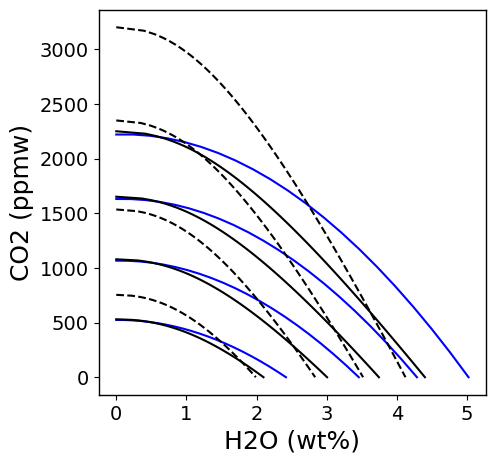

In [30]:
fig, (ax1) = plt.subplots(1, 1, figsize=(5,5))

# Plotting results

for tool in ['vf_isobars','vc2_isobars_n','vc2_isobars_nn']:
    if tool == 'vf_isobars':
        line = '-b'
    elif tool == 'vc2_isobars_n':
        line = '-k'
    elif tool == 'vc2_isobars_nn':
        line = '--k'
    data = eval(tool)
    for P in [500,1000,1500,2000]:
        ax1.plot(data[data["P_bar"]==P]["H2O_wtpc"], data[data["P_bar"]==P]["CO2_ppm"], line)

ax1.set_xlabel('H2O (wt%)')
ax1.set_ylabel('CO2 (ppmw)')